# GuardWatch Emergency Response Time Prediction

## Mission

GuardWatch is a wearable safety solution designed to help victims of domestic violence and other emergency situations quickly alert nearby emergency responders. This project applies machine learning regression techniques to predict the estimated emergency response time based on dispatch and incident information.

## Objective

The objective of this project is to:

- Explore and preprocess an African emergency medical services dataset.
- Perform feature engineering and data visualization.
- Compare multiple regression algorithms.
- Select and save the best-performing model.
- Deploy the model through a FastAPI service.
- Integrate the API into a Flutter mobile application.

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Regression Models
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Model Saving
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot settings
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("ambulance_established_ems.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.head()
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 10000
Columns: 29


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,10000.0,5000.5000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
national_number_used,10000.0,0.6450,0.478537,0.0,0.00,1.0,1.00,1.0
dispatch_center_used,10000.0,0.6968,0.459664,0.0,0.00,1.0,1.00,1.0
call_to_dispatch_min,10000.0,3.2705,2.175776,1.0,2.00,3.0,4.00,29.0
ambulance_available,10000.0,0.8333,0.372726,0.0,1.00,1.0,1.00,1.0
response_time_min,10000.0,34.0011,31.645534,0.0,12.00,27.0,48.00,299.0
on_scene_time_min,10000.0,12.0654,7.045132,0.0,8.00,13.0,17.00,35.0
transport_time_min,10000.0,22.4277,15.429854,0.0,13.00,22.0,31.00,126.0
total_call_time_min,10000.0,71.2110,45.861786,0.0,48.00,70.0,98.00,346.0
met_target_response,10000.0,0.1437,0.350803,0.0,0.00,0.0,0.00,1.0


In [ ]:
missing = df.isnull().sum()

missing[missing > 0]

,0


In [ ]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [ ]:
target = "response_time_min"

print(df[target].describe())

count    10000.000000
mean        34.001100
std         31.645534
min          0.000000
25%         12.000000
50%         27.000000
75%         48.000000
max        299.000000
Name: response_time_min, dtype: float64


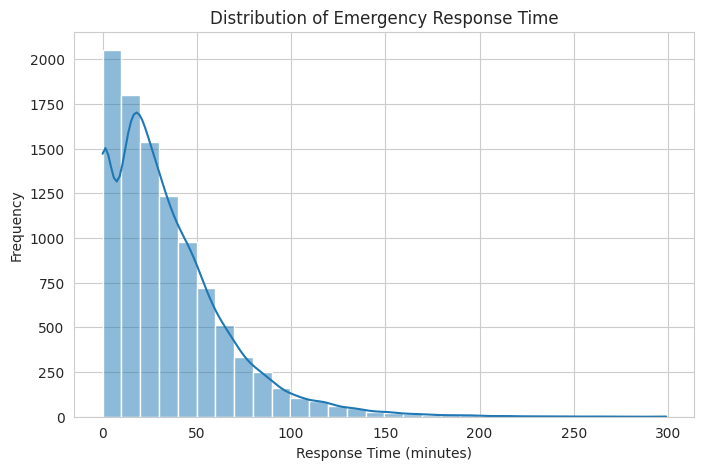

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df[target], bins=30, kde=True)

plt.title("Distribution of Emergency Response Time")
plt.xlabel("Response Time (minutes)")
plt.ylabel("Frequency")

plt.show()

In [ ]:
numeric_df = df.select_dtypes(include=["number"])

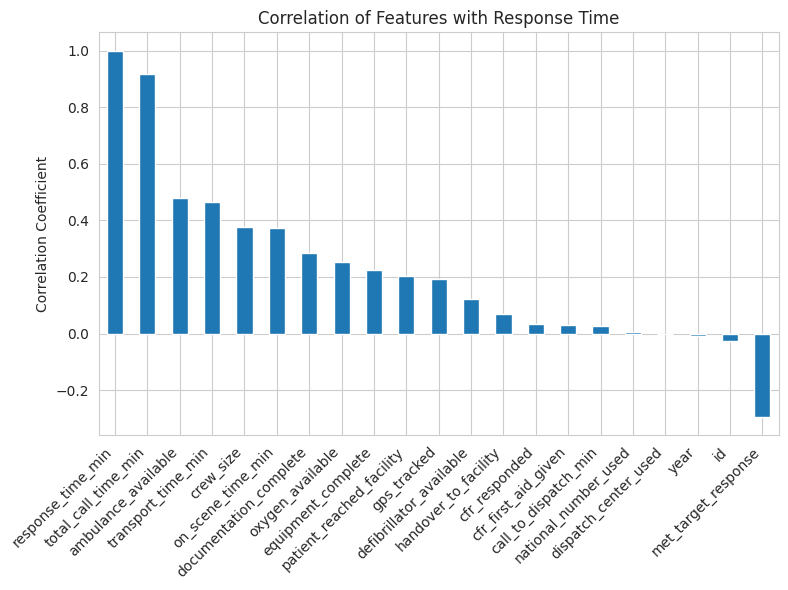

In [ ]:
# Correlation of numerical features with the target variable
target_corr = (
    numeric_df.corr()["response_time_min"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 6))
target_corr.plot(kind="bar")

plt.title("Correlation of Features with Response Time")
plt.ylabel("Correlation Coefficient")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# Check for missing values
missing = df.isnull().sum()
missing = missing[missing > 0]

if missing.empty:
    print("No missing values were found in the dataset.")
else:
    plt.figure(figsize=(8,4))
    missing.sort_values().plot(kind="barh")
    plt.title("Missing Values by Column")
    plt.xlabel("Number of Missing Values")
    plt.show()

No missing values were found in the dataset.


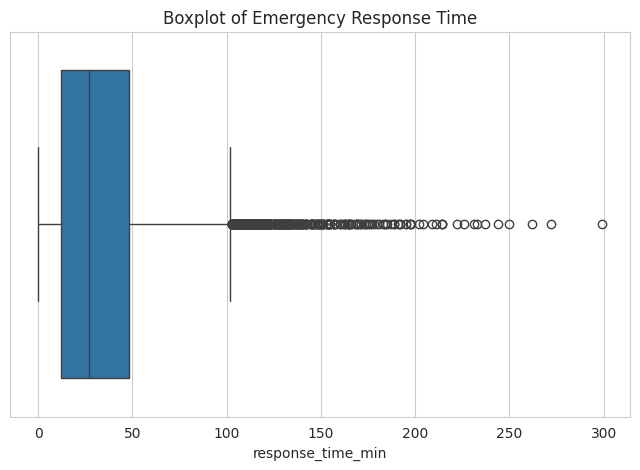

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df[target])

plt.title("Boxplot of Emergency Response Time")

plt.show()

### Interpretation

The boxplot shows that most emergency response times fall between approximately 10 and 50 minutes. However, several unusually large response times exist, extending beyond 300 minutes.

These observations may represent incidents in remote locations, severe traffic congestion, ambulance shortages, or other operational delays.

Since these values are realistic for emergency services rather than obvious data entry errors, they will be retained during model training. Tree-based models such as Decision Trees and Random Forests are generally more robust to outliers than linear regression models, making this comparison particularly valuable.

In [ ]:
# Target variable
target = "response_time_min"

# Columns that introduce data leakage or have no predictive value
columns_to_drop = [
    "id",
    "response_time_min",
    "total_call_time_min",
    "transport_time_min",
    "on_scene_time_min"
]

# Features
X = df.drop(columns=columns_to_drop)

# Target
y = df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (10000, 24)
Target shape: (10000,)


In [10]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical Features")
print(categorical_features)

print("\nNumerical Features")
print(numerical_features)

Categorical Features
['location', 'time_of_day', 'day_of_week', 'call_type', 'priority', 'caller_type', 'highest_qualification', 'alternative_transport']

Numerical Features
['national_number_used', 'dispatch_center_used', 'call_to_dispatch_min', 'ambulance_available', 'crew_size', 'equipment_complete', 'oxygen_available', 'defibrillator_available', 'gps_tracked', 'year']


In [8]:
columns_to_check = [
    "national_number_used",
    "dispatch_center_used",
    "met_target_response",
    "cfr_responded",
    "cfr_first_aid_given",
    "patient_reached_facility",
    "handover_to_facility",
    "documentation_complete"
]

for col in columns_to_check:
    print(f"\n===== {col} =====")
    print(df[col].value_counts())


===== national_number_used =====
national_number_used
1    6450
0    3550
Name: count, dtype: int64

===== dispatch_center_used =====
dispatch_center_used
1    6968
0    3032
Name: count, dtype: int64

===== met_target_response =====
met_target_response
0    8563
1    1437
Name: count, dtype: int64

===== cfr_responded =====
cfr_responded
0    8421
1    1579
Name: count, dtype: int64

===== cfr_first_aid_given =====
cfr_first_aid_given
0    8901
1    1099
Name: count, dtype: int64

===== patient_reached_facility =====
patient_reached_facility
1    9655
0     345
Name: count, dtype: int64

===== handover_to_facility =====
handover_to_facility
1    8168
0    1832
Name: count, dtype: int64

===== documentation_complete =====
documentation_complete
1    6266
0    3734
Name: count, dtype: int64


## Feature Selection

After exploring the dataset, features were evaluated based on whether they would realistically be available at the moment an emergency call is received.

Several variables were removed because they introduce **data leakage**. Data leakage occurs when a model is trained using information that would only become available after the event being predicted has already happened. Using these variables would artificially inflate model performance while making the model unusable in a real deployment.

Examples include:

- `met_target_response`
- `cfr_responded`
- `cfr_first_aid_given`
- `patient_reached_facility`
- `handover_to_facility`
- `documentation_complete`
- `transport_time_min`
- `on_scene_time_min`
- `total_call_time_min`

These variables describe what happened after emergency responders had already been dispatched and therefore cannot be used to predict the initial response time.

In [9]:
# Target variable
target = "response_time_min"

# Columns to remove
columns_to_drop = [
    "id",
    target,
    "total_call_time_min",
    "transport_time_min",
    "on_scene_time_min",
    "met_target_response",
    "cfr_responded",
    "cfr_first_aid_given",
    "patient_reached_facility",
    "handover_to_facility",
    "documentation_complete"
]

# Feature matrix
X = df.drop(columns=columns_to_drop)

# Target
y = df[target]

print("Features remaining:", X.columns.tolist())
print("\nNumber of features:", X.shape[1])

Features remaining: ['location', 'time_of_day', 'day_of_week', 'call_type', 'priority', 'caller_type', 'national_number_used', 'dispatch_center_used', 'call_to_dispatch_min', 'ambulance_available', 'crew_size', 'highest_qualification', 'equipment_complete', 'oxygen_available', 'defibrillator_available', 'gps_tracked', 'alternative_transport', 'year']

Number of features: 18


In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (8000, 18)
Testing samples: (2000, 18)
